# Training Curves Plotting
Notebook per parsificare i log di training (`slurm-train-*.log`) e visualizzare le curve principali.

In [48]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [49]:
# Imposta il file di log desiderato; di default usa l'ultimo slurm-train-*.log
logs_dir = Path('../experiments/logs')
candidate_logs = sorted(logs_dir.glob('slurm-train-*.log'))

if not candidate_logs:
    raise FileNotFoundError(f'Nessun log trovato in {logs_dir.resolve()}')

log_path = candidate_logs[-1]
#log_path = Path('../experiments/logs/slurm-train-4208.log')
print(f'Using log file: {log_path}')

Using log file: ..\experiments\logs\slurm-train-4246.log


In [50]:
epoch_old_re = re.compile(
    r'^\[epoch\s+(?P<epoch>\d+)\]\s+'
    r'train_loss=(?P<train_loss>[0-9]*\.?[0-9]+)\s+'
    r'train_acc=(?P<train_acc>[0-9]*\.?[0-9]+)\s+'
    r'val_map@1=(?P<val_map1>[0-9]*\.?[0-9]+)\s+'
    r'val_map@5=(?P<val_map5>[0-9]*\.?[0-9]+)\s+'
    r'val_map@10=(?P<val_map10>[0-9]*\.?[0-9]+)\s+'
    r'best=(?P<best>[0-9]*\.?[0-9]+)'
)

line_header_re = re.compile(r'^\[(?P<tag>[^\]]+)\]\s+(?P<body>.+)$')
kv_re = re.compile(r'(?P<key>[A-Za-z0-9_@]+)=(?P<value>\S+)')

epoch_rows = []

with log_path.open('r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()

        m_epoch = epoch_old_re.match(line)
        if m_epoch:
            row = m_epoch.groupdict()
            row['epoch'] = int(row['epoch'])
            for k in ('train_loss', 'train_acc', 'val_map1', 'val_map5', 'val_map10', 'best'):
                row[k] = float(row[k])
            row['hard_pos'] = float('nan')
            row['hard_neg'] = float('nan')
            row['margin'] = float('nan')
            row['mining'] = None
            row['valid_anchors'] = float('nan')
            row['total_anchors'] = float('nan')
            row['anchor_ratio'] = float('nan')
            epoch_rows.append(row)
            continue

        m_header = line_header_re.match(line)
        if not m_header:
            continue

        tag = m_header.group('tag').strip().lower()
        if not tag.startswith('triplet epoch'):
            continue

        m_epoch_num = re.search(r'epoch\s+(\d+)', tag)
        if not m_epoch_num:
            continue

        row = {
            'epoch': int(m_epoch_num.group(1)),
            'train_acc': float('nan'),
        }

        for m_kv in kv_re.finditer(m_header.group('body')):
            raw_key = m_kv.group('key')
            value = m_kv.group('value')

            key = raw_key
            if raw_key == 'loss':
                key = 'train_loss'
            elif raw_key.startswith('val_map@'):
                key = raw_key.replace('val_map@', 'val_map')

            num_den = re.match(r'^(\d+)\/(\d+)$', value)
            if num_den:
                numerator = int(num_den.group(1))
                denominator = int(num_den.group(2))
                if key == 'valid_anchors':
                    row['valid_anchors'] = numerator
                    row['total_anchors'] = denominator
                    row['anchor_ratio'] = (numerator / denominator) if denominator else float('nan')
                else:
                    row[key] = value
                continue

            parsed_value = None
            try:
                parsed_value = float(value)
            except ValueError:
                parsed_value = value

            row[key] = parsed_value

        epoch_rows.append(row)

df_epoch = pd.DataFrame(epoch_rows)
base_columns = [
    'epoch',
    'train_loss',
    'train_acc',
    'margin',
    'hard_pos',
    'hard_neg',
    'valid_anchors',
    'total_anchors',
    'anchor_ratio',
    'mining',
    'val_map1',
    'val_map5',
    'val_map10',
    'best',
]

if not df_epoch.empty:
    for col in base_columns:
        if col not in df_epoch.columns:
            df_epoch[col] = float('nan') if col != 'mining' else None
    extra_cols = [c for c in df_epoch.columns if c not in base_columns]
    df_epoch = df_epoch.sort_values('epoch').reset_index(drop=True)
    df_epoch = df_epoch[base_columns + extra_cols]
else:
    df_epoch = pd.DataFrame(columns=base_columns)

print(f'Epoch records: {len(df_epoch)}')
df_epoch.tail()

Epoch records: 100


,epoch,train_loss,train_acc,margin,hard_pos,hard_neg,valid_anchors,total_anchors,anchor_ratio,mining,val_map1,val_map5,val_map10,best
95,96,0.0804,NaN,0.2,1.5770,1.8519,340992,340992,1.0,hard,0.7020,0.6025,0.5410,0.6034
96,97,0.0792,NaN,0.2,1.6044,1.8865,340992,340992,1.0,hard,0.7014,0.6014,0.5397,0.6034
97,98,0.0795,NaN,0.2,1.6161,1.8983,340992,340992,1.0,hard,0.7002,0.6010,0.5400,0.6034
98,99,0.0786,NaN,0.2,1.6238,1.9087,340992,340992,1.0,hard,0.6996,0.5994,0.5377,0.6034
99,100,0.0781,NaN,0.2,1.6363,1.9237,340992,340992,1.0,hard,0.6989,0.6002,0.5387,0.6034


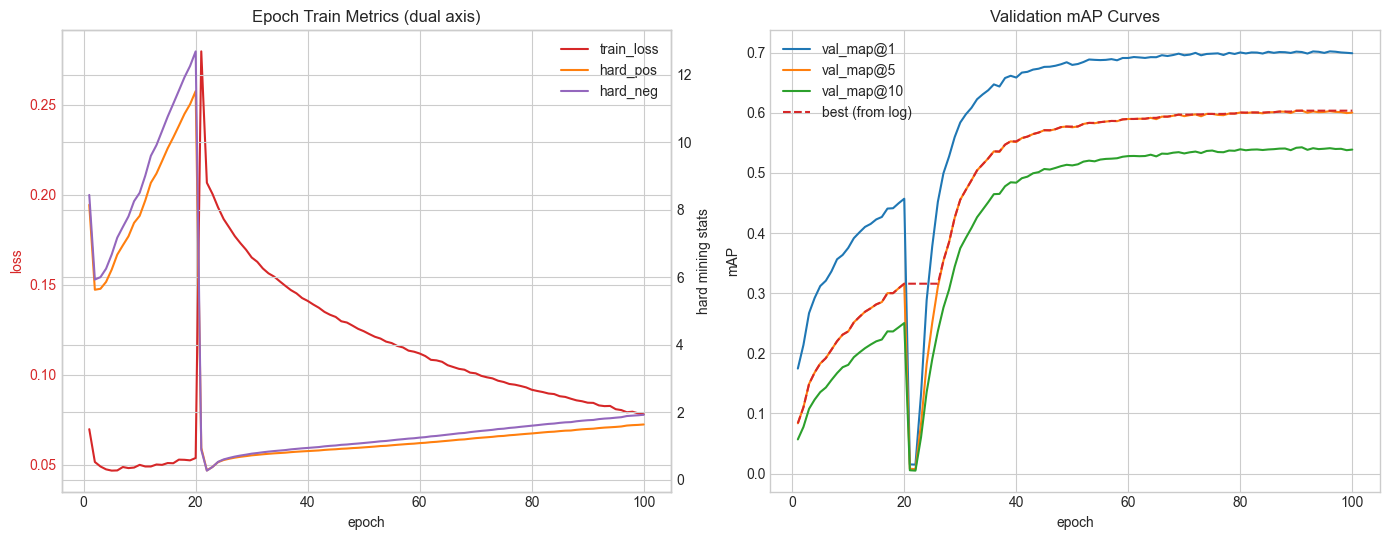

In [51]:
if df_epoch.empty:
    raise ValueError('Nessuna metrica trovata nel log selezionato.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax_epoch = axes[0]
ax_epoch_aux = ax_epoch.twinx()

loss_line = ax_epoch.plot(
    df_epoch['epoch'],
    df_epoch['train_loss'],
    color='tab:red',
    label='train_loss',
)

aux_lines = []
if 'train_acc' in df_epoch.columns and df_epoch['train_acc'].notna().any():
    aux_lines += ax_epoch_aux.plot(
        df_epoch['epoch'],
        df_epoch['train_acc'],
        color='tab:green',
        label='train_acc',
    )
    ax_epoch_aux.set_ylabel('accuracy', color='tab:green')
    ax_epoch_aux.tick_params(axis='y', labelcolor='tab:green')
elif (
    'hard_pos' in df_epoch.columns
    and 'hard_neg' in df_epoch.columns
    and (df_epoch['hard_pos'].notna().any() or df_epoch['hard_neg'].notna().any())
):
    aux_lines += ax_epoch_aux.plot(
        df_epoch['epoch'],
        df_epoch['hard_pos'],
        color='tab:orange',
        label='hard_pos',
    )
    aux_lines += ax_epoch_aux.plot(
        df_epoch['epoch'],
        df_epoch['hard_neg'],
        color='tab:purple',
        label='hard_neg',
    )
    ax_epoch_aux.set_ylabel('hard mining stats')

ax_epoch.set_title('Epoch Train Metrics (dual axis)')
ax_epoch.set_xlabel('epoch')
ax_epoch.set_ylabel('loss', color='tab:red')
ax_epoch.tick_params(axis='y', labelcolor='tab:red')

lines = loss_line + aux_lines
labels = [line.get_label() for line in lines]
ax_epoch.legend(lines, labels, loc='best')

axes[1].plot(df_epoch['epoch'], df_epoch['val_map1'], label='val_map@1')
axes[1].plot(df_epoch['epoch'], df_epoch['val_map5'], label='val_map@5')
axes[1].plot(df_epoch['epoch'], df_epoch['val_map10'], label='val_map@10')
axes[1].plot(df_epoch['epoch'], df_epoch['best'], linestyle='--', linewidth=1.5, label='best (from log)')
axes[1].set_title('Validation mAP Curves')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('mAP')
axes[1].legend()

fig.tight_layout()
plt.show()

In [52]:
# Salvataggio opzionale figure
save_fig = False
output_path = Path('../figures/training_curves.png')

if save_fig:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f'Figure salvata in: {output_path}')
else:
    print('save_fig=False: nessun file salvato')

save_fig=False: nessun file salvato
